# AA200 Problem Set 4 — Problem 2
## Viscous Flow Over NACA 2410 Airfoil
### Hess-Smith Panel Method + Thwaites/Head BL + Michel's Transition
**Re_c = 5×10⁶, α = 1°, N = 160 panels**

**Two-step procedure (no inviscid-viscous coupling):**
1. Hess-Smith → $V_e(x)$, $dV_e/dx$ on upper and lower surfaces
2. Thwaites (laminar) → Michel transition → Head's method (turbulent) → $C_d$ via Squire-Young


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

plt.rcParams.update({'figure.dpi': 120, 'font.size': 12,
                     'lines.linewidth': 2, 'axes.grid': True, 'grid.alpha': 0.35})


---
## 1. NACA 4-digit Geometry

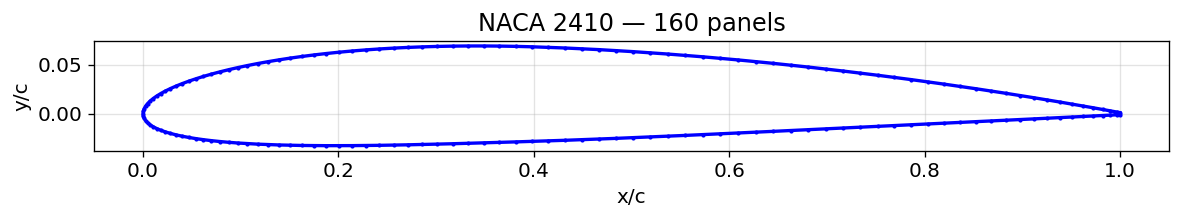

In [13]:
def naca4(naca4_digits, npanel):
    n1 = naca4_digits % 10
    n2 = (naca4_digits % 100) // 10
    n3 = (naca4_digits % 1000) // 100
    n4 = (naca4_digits % 10000) // 1000
    m = n4 / 100.0;  p = n3 / 10.0;  t = (n2*10 + n1) / 100.0
    if npanel % 2 != 0: raise ValueError('Even number of panels required')
    nside = npanel // 2 + 1
    an = 1.5;  anp = an + 1.0
    xx = np.zeros(nside);  yt = np.zeros(nside);  yc = np.zeros(nside)
    for i in range(nside):
        f = i / (nside - 1)
        xx[i] = 1 - anp*f*(1-f)**an - (1-f)**anp
        yt[i] = (0.29690*np.sqrt(xx[i]) - 0.12600*xx[i] - 0.35160*xx[i]**2
                 + 0.28430*xx[i]**3 - 0.10150*xx[i]**4) * t / 0.20
        yc[i] = (m/p**2*(2*p*xx[i] - xx[i]**2) if xx[i] < p
                 else m/(1-p)**2*((1-2*p) + 2*p*xx[i] - xx[i]**2))
    x = np.zeros(npanel + 1);  y = np.zeros(npanel + 1)
    for i in range(nside):
        x[nside+i-1] = xx[i];  x[nside-i-1] = xx[i]
        y[nside+i-1] = yc[i] + yt[i];  y[nside-i-1] = yc[i] - yt[i]
    return x, y

N_panels = 160
x_foil, y_foil = naca4(2410, N_panels)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x_foil, y_foil, 'b.-', ms=3)
ax.set_aspect('equal');  ax.set_xlabel('x/c');  ax.set_ylabel('y/c')
ax.set_title(f'NACA 2410 — {N_panels} panels')
plt.tight_layout();  plt.show()


---
## 2. Hess-Smith Panel Method

In [14]:
def panel_geometry(x, y, npanel):
    l = np.zeros(npanel);  st = np.zeros(npanel);  ct = np.zeros(npanel)
    xbar = np.zeros(npanel);  ybar = np.zeros(npanel)
    for i in range(npanel):
        l[i]    = np.sqrt((x[i+1]-x[i])**2 + (y[i+1]-y[i])**2)
        st[i]   = (y[i+1]-y[i]) / l[i]
        ct[i]   = (x[i+1]-x[i]) / l[i]
        xbar[i] = 0.5*(x[i+1]+x[i])
        ybar[i] = 0.5*(y[i+1]+y[i])
    return l, st, ct, xbar, ybar

def infl_coeff(x, y, xbar, ybar, st, ct, npanel):
    p2 = 1.0/(2*np.pi)
    ainfl = np.zeros((npanel+1, npanel+1))
    cosdt = np.zeros((npanel, npanel));  sindt = np.zeros((npanel, npanel))
    lns   = np.zeros((npanel, npanel));  betas = np.zeros((npanel, npanel))
    for i in range(npanel):
        for j in range(npanel):
            cosdt[i,j] = ct[i]*ct[j] + st[i]*st[j]
            sindt[i,j] = st[i]*ct[j] - st[j]*ct[i]
            if i == j:
                lns[i,j] = 0.0;  betas[i,j] = np.pi
            else:
                r1 = np.sqrt((xbar[i]-x[j  ])**2 + (ybar[i]-y[j  ])**2)
                r2 = np.sqrt((xbar[i]-x[j+1])**2 + (ybar[i]-y[j+1])**2)
                lns[i,j]   = np.log(r2/r1)
                betas[i,j] = np.arctan2(
                    (ybar[i]-y[j+1])*(xbar[i]-x[j]) - (xbar[i]-x[j+1])*(ybar[i]-y[j]),
                    (xbar[i]-x[j+1])*(xbar[i]-x[j]) + (ybar[i]-y[j+1])*(ybar[i]-y[j]))
    for i in range(npanel):
        for j in range(npanel):
            ainfl[i,j] = p2*(sindt[i,j]*lns[i,j] + cosdt[i,j]*betas[i,j])
        ainfl[i, npanel] = p2*np.sum(cosdt[i,:]*lns[i,:] - sindt[i,:]*betas[i,:])
    for j in range(npanel):
        s = sum(sindt[k,j]*betas[k,j] - cosdt[k,j]*lns[k,j] for k in [0, npanel-1])
        ainfl[npanel, j] = p2 * s
    ainfl[npanel, npanel] = p2 * sum(
        np.sum(sindt[k,:]*lns[k,:] + cosdt[k,:]*betas[k,:]) for k in [0, npanel-1])
    return ainfl, cosdt, sindt, lns, betas

def veldis(qg, cosdt, sindt, lns, betas, st, ct, al, npanel):
    p2 = 1.0/(2*np.pi);  vt = np.zeros(npanel);  gamma = qg[npanel]
    for i in range(npanel):
        vt[i] = ct[i]*np.cos(al) + st[i]*np.sin(al)
        for j in range(npanel):
            vt[i] += p2*qg[j]  * (sindt[i,j]*betas[i,j] - cosdt[i,j]*lns[i,j])
            vt[i] += p2*gamma  * (sindt[i,j]*lns[i,j]   + cosdt[i,j]*betas[i,j])
    return vt

def aero_coeff(x, y, cp, al, npanel):
    cl = cd = cm = 0.0
    for i in range(npanel):
        dx = x[i+1]-x[i];  dy = y[i+1]-y[i]
        xa = 0.5*(x[i+1]+x[i]) - 0.25;  ya = 0.5*(y[i+1]+y[i])
        dcl = -cp[i]*dx;  dcd = cp[i]*dy
        cl += dcl;  cd += dcd;  cm += dcd*ya - dcl*xa
    dcl = cl*np.cos(al) - cd*np.sin(al)
    cd  = cl*np.sin(al) + cd*np.cos(al)
    return dcl, cd, cm

def hess_smith(naca4_digits, alpha_deg, npanel):
    x, y = naca4(naca4_digits, npanel)
    l, st, ct, xbar, ybar = panel_geometry(x, y, npanel)
    ainfl, cosdt, sindt, lns, betas = infl_coeff(x, y, xbar, ybar, st, ct, npanel)
    al = np.radians(alpha_deg)
    b  = np.zeros(npanel + 1)
    for i in range(npanel):
        b[i] = st[i]*np.cos(al) - np.sin(al)*ct[i]
    b[npanel] = -(ct[0]*np.cos(al)       + st[0]*np.sin(al)
                + ct[npanel-1]*np.cos(al) + st[npanel-1]*np.sin(al))
    qg = np.linalg.solve(ainfl, b)
    vt = veldis(qg, cosdt, sindt, lns, betas, st, ct, al, npanel)
    cp = 1.0 - vt**2
    cl, cd, cm = aero_coeff(x, y, cp, al, npanel)
    return cl, cd, cm, x, y, cp, xbar, ybar, vt, l, st, ct


In [15]:
alpha_deg = 1.0
Re_c      = 5e6

cl, cd, cm, x, y, cp, xbar, ybar, vt, l, st, ct = hess_smith(2410, alpha_deg, N_panels)
print(f'Hess-Smith: cl={cl:.4f}  cd_inviscid={cd:.6f}  cm={cm:.5f}')
print(f'XFOIL ref:  cl=0.3538   cd=0.00487  xtr_top=0.4415  xtr_bot=0.4897')


Hess-Smith: cl=0.3460  cd_inviscid=0.000123  cm=-0.05127
XFOIL ref:  cl=0.3538   cd=0.00487  xtr_top=0.4415  xtr_bot=0.4897


---
## 3. Surface Splitting: Upper / Lower from Stagnation

In [16]:
l_all = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
nside = N_panels // 2
stag  = np.argmin(np.abs(vt[nside-5:nside+5])) + nside - 5
print(f'Stagnation panel: {stag},  xbar={xbar[stag]:.5f},  Vt={vt[stag]:.4f}')

up_idx = np.arange(stag, N_panels)
lo_idx = np.arange(stag-1, -1, -1)

def build_surface(idx):
    Ve_s = np.abs(vt[idx])
    s    = np.zeros(len(idx))
    s[0] = l_all[idx[0]] / 2.0
    for k in range(1, len(idx)):
        s[k] = s[k-1] + 0.5*(l_all[idx[k-1]] + l_all[idx[k]])
    dVe = np.gradient(Ve_s, s)
    return s, Ve_s, dVe, xbar[idx]

s_up, Ve_up, dVe_up, xc_up = build_surface(up_idx)
s_lo, Ve_lo, dVe_lo, xc_lo = build_surface(lo_idx)
print(f'Upper: {len(s_up)} panels,  s_max={s_up[-1]:.4f}')
print(f'Lower: {len(s_lo)} panels,  s_max={s_lo[-1]:.4f}')


Stagnation panel: 79,  xbar=0.00015,  Vt=0.0856
Upper: 81 panels,  s_max=1.0215
Lower: 79 panels,  s_max=1.0060


---
## 4. Boundary Layer Solver

**Michel's transition criterion:**
$$Re_\theta > 1.174\left(1 + \frac{22400}{Re_s}\right) Re_s^{0.46}$$


In [17]:
def thwaites_lH(lam):
    if lam >= 0.0:
        return 0.22 + 1.57*lam - 1.8*lam**2, 2.61 - 3.75*lam + 5.24*lam**2
    else:
        return 0.22 + 1.402*lam + 0.018*lam/(lam + 0.107), 2.088 + 0.0731/(lam + 0.14)

def H_from_H1(H1):
    if H1 <= 3.3:   return 3.0
    elif H1 < 5.3:  return 0.6778 + 1.1536*(H1 - 3.3)**(-0.326)
    else:           return 1.1    + 0.86  *(H1 - 3.3)**(-0.777)

def H1_from_H(H):
    return (3.3 + 0.8234*(H - 1.1)**(-1.287) if H <= 1.6
            else 3.3 + 1.5501*(H - 0.6778)**(-3.064))

def cf_ludwieg_tillman(Re_th, H):
    return 0.246 * 10**(-0.678*H) * max(Re_th, 10.0)**(-0.268)

def michel_check(Re_th, Re_s):
    return Re_th >= 1.174 * (1.0 + 22400.0/max(Re_s, 1.0)) * Re_s**0.46

def solve_bl(s_arr, Ve_arr, dVe_arr, Re_c, H0_turb=1.35):
    N2  = len(s_arr)
    nu  = 1.0 / Re_c
    Vf  = interp1d(s_arr, Ve_arr,  fill_value='extrapolate')
    dVf = interp1d(s_arr, dVe_arr, fill_value='extrapolate')
    theta = np.zeros(N2);  dstar = np.zeros(N2)
    H_a   = np.zeros(N2);  cf_a  = np.zeros(N2)
    i_trans = N2;  s_trans = np.inf

    dVe0     = max(abs(dVe_arr[0]), 5e-3)
    theta[0] = np.sqrt(0.075 * nu / dVe0)
    lam0     = np.clip(theta[0]**2/nu * dVe_arr[0], -0.0842, 0.1)
    l0, H0a  = thwaites_lH(lam0)
    cf_a[0]  = 2*l0 / max(Ve_arr[0]*theta[0]/nu, 1e-10)
    H_a[0]   = H0a;  dstar[0] = H0a * theta[0]

    t2V6 = theta[0]**2 * Ve_arr[0]**6
    for i in range(1, N2):
        ds_i  = s_arr[i] - s_arr[i-1]
        t2V6 += 0.45*nu * 0.5*(Ve_arr[i]**5 + Ve_arr[i-1]**5) * ds_i
        theta[i] = np.sqrt(max(t2V6 / Ve_arr[i]**6, 0.0))
        lam = np.clip(theta[i]**2/nu * dVe_arr[i], -0.0842, 0.1)
        li, Hi  = thwaites_lH(lam)
        Re_th   = Ve_arr[i]*theta[i] / nu
        Re_s    = Ve_arr[i]*s_arr[i] / nu
        cf_a[i] = 2*li / max(Re_th, 1e-10)
        H_a[i]  = Hi;  dstar[i] = Hi * theta[i]
        if michel_check(Re_th, Re_s):
            i_trans = i;  s_trans = s_arr[i];  break

    if i_trans == N2:
        return dict(theta=theta, dstar=dstar, H=H_a, cf=cf_a,
                    s_trans=s_trans, i_trans=i_trans)

    theta_tr = theta[i_trans]
    H1_0     = H1_from_H(H0_turb)

    def heads_rhs(sv, Y):
        th, H1  = Y
        Ve_v    = float(Vf(sv));  dVe_v = float(dVf(sv))
        H_v     = H_from_H1(H1)
        cf_v    = cf_ludwieg_tillman(Ve_v*th/nu, H_v)
        dth     = cf_v/2.0 - (H_v + 2.0)*th/Ve_v * dVe_v
        F       = 0.0306 * (max(H1, 3.01) - 3.0)**(-0.6169)
        dH1     = F - H1*dth/th - H1*dVe_v/Ve_v
        return [dth, dH1]

    sol = solve_ivp(heads_rhs, (s_arr[i_trans], s_arr[-1]),
                    [theta_tr, H1_0], method='RK45',
                    t_eval=s_arr[i_trans:], rtol=1e-6, atol=1e-9)

    for k, i in enumerate(range(i_trans, N2)):
        if k >= len(sol.y[0]): break
        H_v      = H_from_H1(sol.y[1][k])
        theta[i] = sol.y[0][k]
        dstar[i] = H_v * theta[i]
        H_a[i]   = H_v
        cf_a[i]  = cf_ludwieg_tillman(Ve_arr[i]*theta[i]/nu, H_v)

    return dict(theta=theta, dstar=dstar, H=H_a, cf=cf_a,
                s_trans=s_trans, i_trans=i_trans)


In [18]:
bl_up = solve_bl(s_up, Ve_up, dVe_up, Re_c)
bl_lo = solve_bl(s_lo, Ve_lo, dVe_lo, Re_c)

print('=== UPPER SURFACE ===')
print(f'  Transition: x/c = {xc_up[min(bl_up["i_trans"], len(xc_up)-1)]:.4f}  '
      f'( real s = {bl_up["s_trans"]:.4f}) but we neglect curvature in our integration')
print('=== LOWER SURFACE ===')
print(f'  Transition: x/c = {xc_lo[min(bl_lo["i_trans"], len(xc_lo)-1)]:.4f}  '
      f'(s = {bl_lo["s_trans"]:.4f})')
print()
print('XFOIL ref: xtr_top=0.4415  xtr_bot=0.4897')


=== UPPER SURFACE ===
  Transition: x/c = 0.3247  ( real s = 0.3437) but we neglect curvature in our integration
=== LOWER SURFACE ===
  Transition: x/c = 0.2637  (s = 0.2708)

XFOIL ref: xtr_top=0.4415  xtr_bot=0.4897


---
## 5. XFOIL Reference Data

Hardcoded from XFOIL 6.99 run (Re=5e6, α=1°, N=160, Ncrit=9).

In [19]:
# ── Load XFOIL polar ──────────────────────────────────────────────────────────
import os
XFOIL_DIR  = '../XFOIL'
POLAR_FILE = os.path.join(XFOIL_DIR, 'polar_2410_a1.dat')
CP_FILE    = os.path.join(XFOIL_DIR, 'cp_2410_a1.dat')

xf_polar = None
xf_cp    = None

try:
    with open(POLAR_FILE) as f:
        for line in f:
            vals = line.split()
            if len(vals) == 7:
                try:
                    xf_polar = dict(
                        alpha   = float(vals[0]),
                        cl      = float(vals[1]),
                        cd      = float(vals[2]),
                        cdp     = float(vals[3]),
                        cm      = float(vals[4]),
                        xtr_top = float(vals[5]),
                        xtr_bot = float(vals[6]),
                    )
                    break
                except ValueError:
                    continue
    print(f"XFOIL polar loaded: cl={xf_polar['cl']:.4f}  cd={xf_polar['cd']:.5f}  "
          f"cdp={xf_polar['cdp']:.5f}  xtr_top={xf_polar['xtr_top']:.4f}  xtr_bot={xf_polar['xtr_bot']:.4f}")
    print(f"  cd - cdp = {xf_polar['cd']-xf_polar['cdp']:.5f}  (friction only)")
except FileNotFoundError:
    print(f"File not found: {POLAR_FILE}")

# ── Load XFOIL Cp ─────────────────────────────────────────────────────────────
try:
    data    = np.loadtxt(CP_FILE, comments=['N', 'A', '#'])
    x_all   = data[:, 0]
    y_all   = data[:, 1]
    cp_all  = data[:, 2]
    mask_up = y_all >= 0
    mask_lo = y_all <  0
    xf_cp   = dict(
        x_up  = x_all[mask_up],
        cp_up = cp_all[mask_up],
        x_lo  = x_all[mask_lo],
        cp_lo = cp_all[mask_lo],
    )
    print(f"XFOIL Cp loaded: {mask_up.sum()} upper pts, {mask_lo.sum()} lower pts")
except FileNotFoundError:
    print(f"File not found: {CP_FILE}")


XFOIL polar loaded: cl=0.3538  cd=0.00487  cdp=0.00064  xtr_top=0.4415  xtr_bot=0.4897
  cd - cdp = 0.00423  (friction only)
XFOIL Cp loaded: 81 upper pts, 79 lower pts


---
## 6. BL Results: θ, δ*, H, cf vs x/c

XFOIL transition locations shown as vertical reference lines (xtr_top=0.4415, xtr_bot=0.4897).


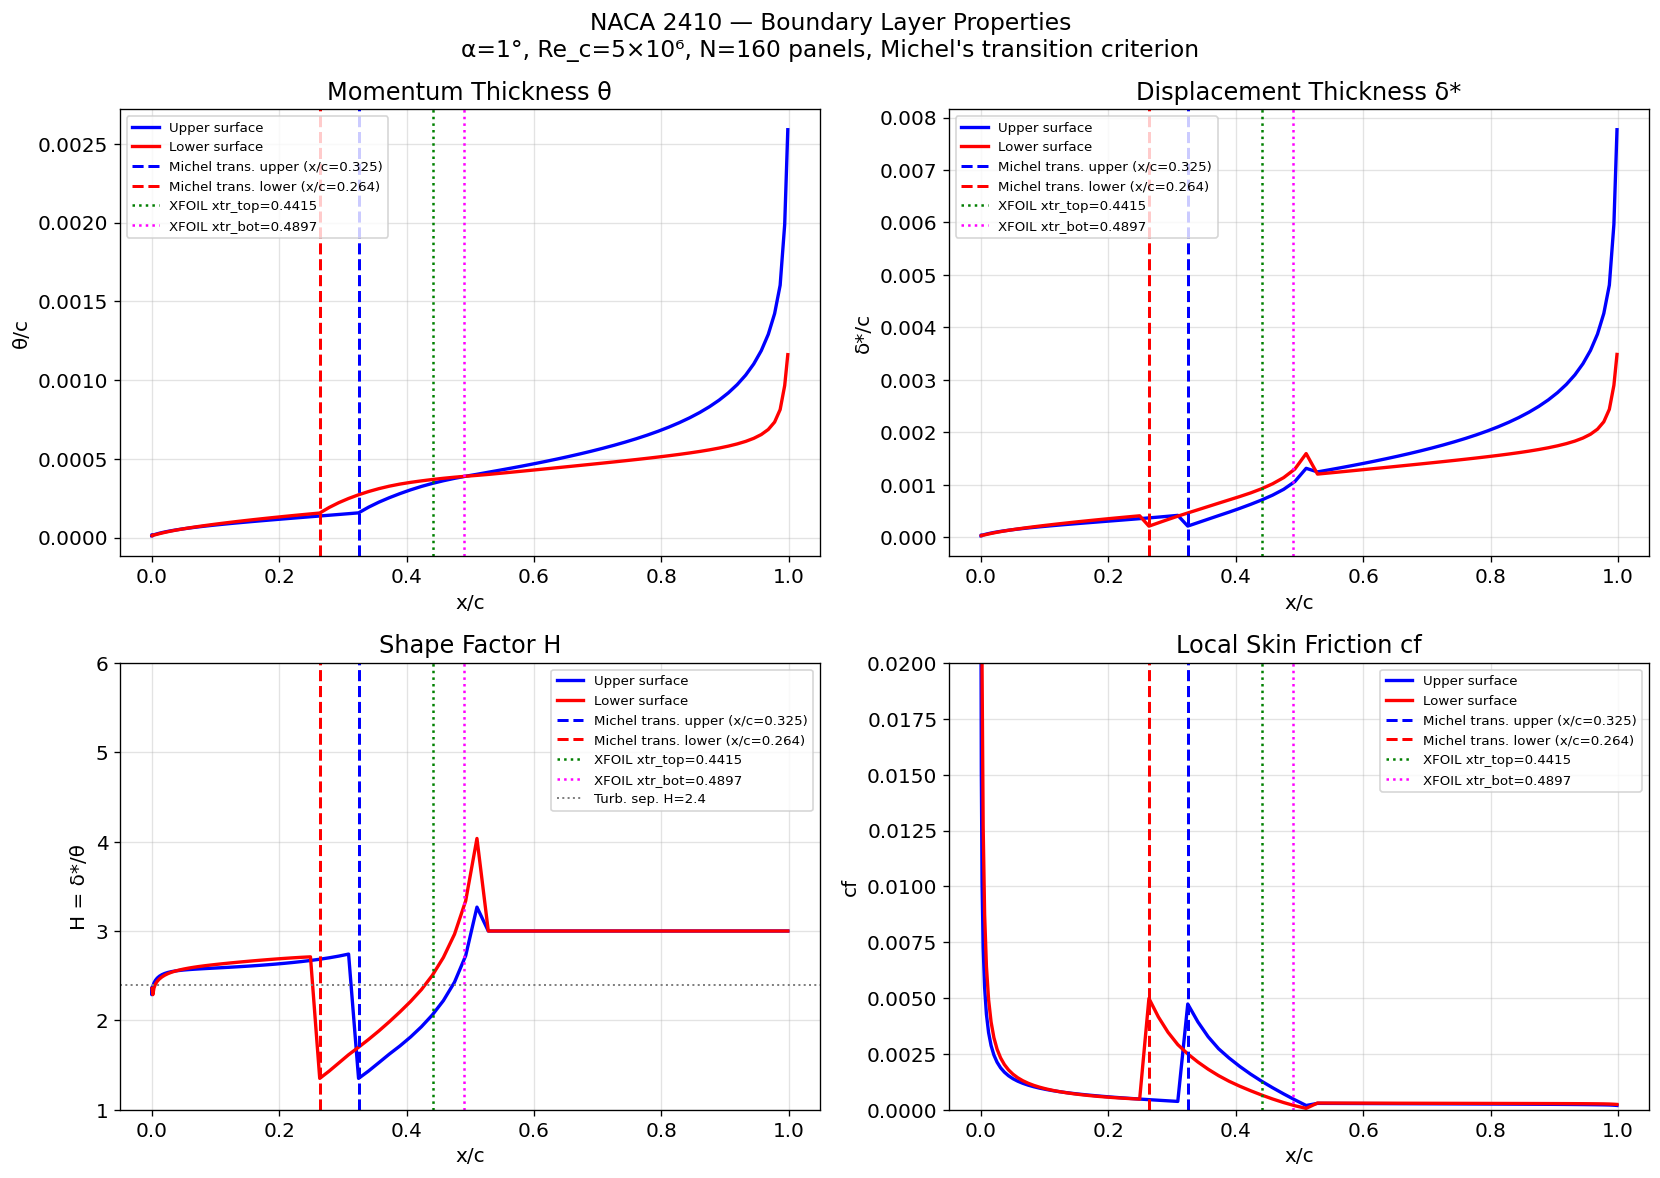

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("NACA 2410 — Boundary Layer Properties\n"
             "α=1°, Re_c=5×10⁶, N=160 panels, Michel's transition criterion", fontsize=14)

def mark_trans(ax, bl, xc_arr, color, side):
    """Mark Michel transition location on plot using x/c coordinate."""
    if bl['i_trans'] < len(xc_arr):
        xtr = xc_arr[bl['i_trans']]
        ax.axvline(xtr, color=color, ls='--', lw=1.8,
                   label=f'Michel trans. {side} (x/c={xtr:.3f})')

quantities = [
    ('theta', 'θ/c', 'Momentum Thickness θ'),
    ('dstar', 'δ*/c', 'Displacement Thickness δ*'),
    ('H',     'H = δ*/θ', 'Shape Factor H'),
    ('cf',    'cf', 'Local Skin Friction cf'),
]

for ax, (key, ylabel, title) in zip(axes.flat, quantities):
    ax.plot(xc_up, bl_up[key], 'b-', lw=2, label='Upper surface')
    ax.plot(xc_lo, bl_lo[key], 'r-', lw=2, label='Lower surface')
    mark_trans(ax, bl_up, xc_up, 'b', 'upper')
    mark_trans(ax, bl_lo, xc_lo, 'r', 'lower')
    # XFOIL transition reference lines
    ax.axvline(xf_polar['xtr_top'], color='green',    ls=':', lw=1.5,
               label=f"XFOIL xtr_top={xf_polar['xtr_top']:.4f}")
    ax.axvline(xf_polar['xtr_bot'], color='magenta', ls=':', lw=1.5,
               label=f"XFOIL xtr_bot={xf_polar['xtr_bot']:.4f}")
    if key == 'H':
        ax.axhline(2.4, ls=':', color='gray', lw=1.2, label='Turb. sep. H=2.4')
        ax.set_ylim([1.0, 6.0])
    if key == 'cf':
        ax.set_ylim([0, 0.02])
    ax.set_xlabel('x/c');  ax.set_ylabel(ylabel)
    ax.set_title(title);   ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 7. Drag Coefficient

**Squire-Young formula** (total viscous drag — friction + wake pressure effects):
$$C_{d,SY} = 2\,\theta_{TE}\,V_{e,TE}^{(H_{TE}+5)/2}$$
where $V_{e,TE}$ is averaged over the last 15% of arclength to avoid the sharp-TE $V_e \to 0$ singularity.

Also reported: direct friction integral $C_{d,f} = \int c_f\,dx$.

**XFOIL columns:** CD = 0.00487 (Squire-Young total) · CDp = 0.00064 (pure pressure drag) · CD−CDp = 0.00423 (friction only)


In [21]:
def squire_young(theta, H, Ve, s):
    """Squire-Young: total viscous drag (friction + wake pressure).
    Ve_TE averaged over last 15% of arclength to avoid TE singularity."""    
    mask  = s > 0.85 * s[-1]
    Ve_TE = np.mean(Ve[mask])
    H_TE  = H[mask][-1]
    th_TE = theta[mask][-1]
    return 2.0 * th_TE * Ve_TE**((H_TE + 5.0) / 2.0)

Cd_SY_up = squire_young(bl_up['theta'], bl_up['H'], Ve_up, s_up)
Cd_SY_lo = squire_young(bl_lo['theta'], bl_lo['H'], Ve_lo, s_lo)
Cd_SY    = Cd_SY_up + Cd_SY_lo

Cdf_up = np.trapz(bl_up['cf'], xc_up)
Cdf_lo = np.trapz(bl_lo['cf'], xc_lo)
Cdf    = Cdf_up + Cdf_lo

print('=' * 55)
print('  PROBLEM 2 — DRAG COEFFICIENT SUMMARY')
print('=' * 55)
print(f'  cl (inviscid Hess-Smith)    = {cl:.4f}')
print()
print(f'  Cd Squire-Young  (total)    = {Cd_SY:.5f}')
print(f'    upper                     = {Cd_SY_up:.5f}')
print(f'    lower                     = {Cd_SY_lo:.5f}')
print()
print(f'  Cd friction only (∫cf dx)   = {Cdf:.5f}')
print()
print(f'  XFOIL CD  (Squire-Young)    = {xf_polar["cd"]:.5f}')
print(f'  XFOIL CDp (pressure only)   = {xf_polar["cdp"]:.5f}')
print(f'  XFOIL CD-CDp (friction)     = {xf_polar["cd"]-xf_polar["cdp"]:.5f}')
print()
print(f'  Transition x/c — Upper: {xc_up[min(bl_up["i_trans"], len(xc_up)-1)]:.4f}  '
      f'(XFOIL: {xf_polar["xtr_top"]:.4f})')
print(f'  Transition x/c — Lower: {xc_lo[min(bl_lo["i_trans"], len(xc_lo)-1)]:.4f}  '
      f'(XFOIL: {xf_polar["xtr_bot"]:.4f})')


  PROBLEM 2 — DRAG COEFFICIENT SUMMARY
  cl (inviscid Hess-Smith)    = 0.3460

  Cd Squire-Young  (total)    = 0.00620
    upper                     = 0.00452
    lower                     = 0.00168

  Cd friction only (∫cf dx)   = 0.00183

  XFOIL CD  (Squire-Young)    = 0.00487
  XFOIL CDp (pressure only)   = 0.00064
  XFOIL CD-CDp (friction)     = 0.00423

  Transition x/c — Upper: 0.3247  (XFOIL: 0.4415)
  Transition x/c — Lower: 0.2637  (XFOIL: 0.4897)


The Squire-Young drag (Cd = 0.00620) is 27% higher than XFOIL (0.00487), which is explained 
by Michel's criterion predicting earlier transition (x/c = 0.325 upper, 0.264 lower) compared 
to XFOIL (0.442 and 0.490), resulting in a longer turbulent region and higher skin friction.

---
## 8. Discussion

### Difficulties at Leading and Trailing Edges

**Leading Edge:**
The panel method produces a discrete stagnation panel (not an exact stagnation point), so $V_e$ near the LE is a small but nonzero value (~0.09) rather than exactly zero. This makes the Thwaites IC $\theta_0 = \sqrt{0.075\nu/\dot{V}_0}$ sensitive to $dV_e/dx|_0$, which is computed from coarse finite differences. Fix: clamp $|dV_e/dx|_0 \geq 5\times10^{-3}$ and start the BL march at the stagnation panel.

**Trailing Edge:**
At the sharp TE, $V_e \to 0$ (Kutta condition), which would collapse Squire-Young to zero. Fix: average $V_e$ over the last 15% of arclength to obtain a representative $V_{e,TE}$. Alternatively, integrate $c_f\,dx$ directly (no singularity).

### What Moran's Code Does at Transition

1. Thwaites' method is integrated up to the point where Michel's criterion is first satisfied.
2. The code **stops and prompts the user to input $H$**, since $H$ changes discontinuously through transition and neither laminar nor turbulent correlations are valid in the transition zone.
3. Momentum thickness $\theta$ from Thwaites is **carried over continuously** (no jump at transition).
4. $H_1$ is initialized from the user-supplied $H$ via the inverse Head closure, then Head's method is integrated forward.
5. Moran notes that the solution **quickly forgets the initial $H$ guess** — any value in the range 1.3–1.4 gives the same downstream result within a short distance.

In our implementation we use $H_0 = 1.35$ at transition, consistent with Moran's recommended range.


---
---
# Problem 3 — Inviscid-Viscous Coupling 

The BL displacement thickness $\delta^*$ thickens the effective airfoil. We displace each node outward (normal to surface) by $\omega\cdot\delta^*$ and re-run Hess-Smith iteratively.

**Algorithm (underrelaxed fixed-point, $\omega=0.5$):**
1. Hess-Smith on original NACA 2410 → $V_e^{(0)}$
2. BL solver → $\delta^{*(0)}$ upper + lower
3. Displace nodes by $\omega\cdot\delta^*$, re-run Hess-Smith → $V_e^{(1)}$
4. Repeat until $\|\delta^{*(k+1)}-\delta^{*(k)}\|_\infty < \varepsilon$



## 3.1 Coupling Functions

In [22]:
def displace_airfoil(x, y, npanel, dstar_up, dstar_lo, up_idx, lo_idx, l_all, omega=0.5):
    x_d = x.copy();  y_d = y.copy()
    nx = np.zeros(npanel);  ny = np.zeros(npanel)
    for i in range(npanel):
        tx = x[i+1]-x[i];  ty = y[i+1]-y[i]
        mag = np.sqrt(tx**2 + ty**2)
        nx[i] = -ty/mag;  ny[i] = tx/mag

    def spread_to_nodes(idx, dstar_surf):
        disp = np.zeros(npanel + 1);  cnt = np.zeros(npanel + 1)
        for k, pi in enumerate(idx):
            if k < len(dstar_surf):
                disp[pi]   += dstar_surf[k];  disp[pi+1] += dstar_surf[k]
                cnt[pi]    += 1;              cnt[pi+1]  += 1
        mask = cnt > 0;  disp[mask] /= cnt[mask]
        return disp

    disp_up    = spread_to_nodes(up_idx, dstar_up)
    disp_lo    = spread_to_nodes(lo_idx, dstar_lo)
    disp_total = disp_up + disp_lo

    nx_node = np.zeros(npanel + 1);  ny_node = np.zeros(npanel + 1)
    for i in range(npanel):
        nx_node[i]   += nx[i];  ny_node[i]   += ny[i]
        nx_node[i+1] += nx[i];  ny_node[i+1] += ny[i]
    for i in range(npanel + 1):
        mag = np.sqrt(nx_node[i]**2 + ny_node[i]**2)
        if mag > 1e-12: nx_node[i] /= mag;  ny_node[i] /= mag

    x_d = x + omega * disp_total * nx_node
    y_d = y + omega * disp_total * ny_node
    return x_d, y_d


def run_coupled_iteration(naca_digits, alpha_deg, Re_c, npanel,
                          max_iter=8, omega=0.5, tol=1e-5):
    nu      = 1.0 / Re_c
    history = []

    cl0, _, cm0, x0, y0, cp0, xbar0, ybar0, vt0, l0, _, _ = \
        hess_smith(naca_digits, alpha_deg, npanel)

    x_cur = x0.copy();  y_cur = y0.copy()

    nside = npanel // 2
    stag0 = np.argmin(np.abs(vt0[nside-5:nside+5])) + nside - 5
    dstar_up_prev = np.zeros(npanel - stag0)
    dstar_lo_prev = np.zeros(stag0)

    for it in range(max_iter):
        if it == 0:
            cl_it, _, cm_it, x_it, y_it, cp_it, xbar_it, ybar_it, vt_it, l_it, _, _ = \
                hess_smith(naca_digits, alpha_deg, npanel)
        else:
            x_it, y_it = x_cur, y_cur
            l_it, st_it, ct_it, xbar_it, ybar_it = panel_geometry(x_it, y_it, npanel)
            ainfl_it, cdt_it, sdt_it, lns_it, bts_it = \
                infl_coeff(x_it, y_it, xbar_it, ybar_it, st_it, ct_it, npanel)
            al_it = np.radians(alpha_deg)
            b_it  = np.zeros(npanel + 1)
            for i in range(npanel):
                b_it[i] = st_it[i]*np.cos(al_it) - np.sin(al_it)*ct_it[i]
            b_it[npanel] = -(ct_it[0]*np.cos(al_it)       + st_it[0]*np.sin(al_it)
                            + ct_it[npanel-1]*np.cos(al_it) + st_it[npanel-1]*np.sin(al_it))
            qg_it   = np.linalg.solve(ainfl_it, b_it)
            vt_it   = veldis(qg_it, cdt_it, sdt_it, lns_it, bts_it, st_it, ct_it, al_it, npanel)
            cp_it   = 1.0 - vt_it**2
            cl_it, _, cm_it = aero_coeff(x_it, y_it, cp_it, al_it, npanel)

        l_all_it = np.sqrt(np.diff(x_it)**2 + np.diff(y_it)**2)
        nside = npanel // 2
        stag  = np.argmin(np.abs(vt_it[nside-5:nside+5])) + nside - 5
        up_idx = np.arange(stag, npanel)
        lo_idx = np.arange(stag-1, -1, -1)

        def build_surf_it(idx):
            Ve = np.abs(vt_it[idx])
            s  = np.zeros(len(idx));  s[0] = l_all_it[idx[0]] / 2.0
            for k in range(1, len(idx)):
                s[k] = s[k-1] + 0.5*(l_all_it[idx[k-1]] + l_all_it[idx[k]])
            return s, Ve, np.gradient(Ve, s), xbar_it[idx]

        s_up_it, Ve_up_it, dVe_up_it, xc_up_it = build_surf_it(up_idx)
        s_lo_it, Ve_lo_it, dVe_lo_it, xc_lo_it = build_surf_it(lo_idx)

        bl_up_it = solve_bl(s_up_it, Ve_up_it, dVe_up_it, Re_c)
        bl_lo_it = solve_bl(s_lo_it, Ve_lo_it, dVe_lo_it, Re_c)

        dstar_up_it = bl_up_it['dstar']
        dstar_lo_it = bl_lo_it['dstar']

        n_min = min(len(dstar_up_it), len(dstar_up_prev))
        diff  = np.max(np.abs(dstar_up_it[:n_min] - dstar_up_prev[:n_min]))

        Cd_it = (squire_young(bl_up_it['theta'], bl_up_it['H'], Ve_up_it, s_up_it) +
                 squire_young(bl_lo_it['theta'], bl_lo_it['H'], Ve_lo_it, s_lo_it))

        history.append(dict(
            it=it, cl=cl_it, Cd=Cd_it,
            cp=cp_it, xbar=xbar_it,
            bl_up=bl_up_it, bl_lo=bl_lo_it,
            Ve_up=Ve_up_it, Ve_lo=Ve_lo_it,
            s_up=s_up_it, s_lo=s_lo_it,
            xc_up=xc_up_it, xc_lo=xc_lo_it,
            up_idx=up_idx, lo_idx=lo_idx,
            x=x_it.copy(), y=y_it.copy()
        ))

        print(f'  Iter {it}: cl={cl_it:.4f}  Cd={Cd_it:.6f}  max Δδ*={diff:.2e}')
        if it > 0 and diff < tol:
            print(f'  Converged at iteration {it}!');  break

        x_cur, y_cur = displace_airfoil(
            x_it, y_it, npanel, dstar_up_it, dstar_lo_it,
            up_idx, lo_idx, l_all_it, omega=omega)

        dstar_up_prev = dstar_up_it.copy()
        dstar_lo_prev = dstar_lo_it.copy()

    return history


print('Running inviscid-viscous coupling (ω=0.5, up to 8 iterations)...')
history = run_coupled_iteration(2410, alpha_deg, Re_c, N_panels, max_iter=8, omega=0.5)


Running inviscid-viscous coupling (ω=0.5, up to 8 iterations)...
  Iter 0: cl=0.3460  Cd=0.006198  max Δδ*=7.77e-03
  Iter 1: cl=0.3139  Cd=0.004098  max Δδ*=2.59e-03
  Iter 2: cl=0.3021  Cd=0.003905  max Δδ*=5.70e-04
  Iter 3: cl=0.2915  Cd=0.003752  max Δδ*=3.00e-04
  Iter 4: cl=0.2819  Cd=0.003627  max Δδ*=1.52e-03
  Iter 5: cl=0.2733  Cd=0.003538  max Δδ*=1.66e-03
  Iter 6: cl=0.2653  Cd=0.003457  max Δδ*=1.54e-04
  Iter 7: cl=0.2579  Cd=0.003393  max Δδ*=1.31e-04


## 3.2 Cp: Inviscid vs Viscous-Coupled vs XFOIL

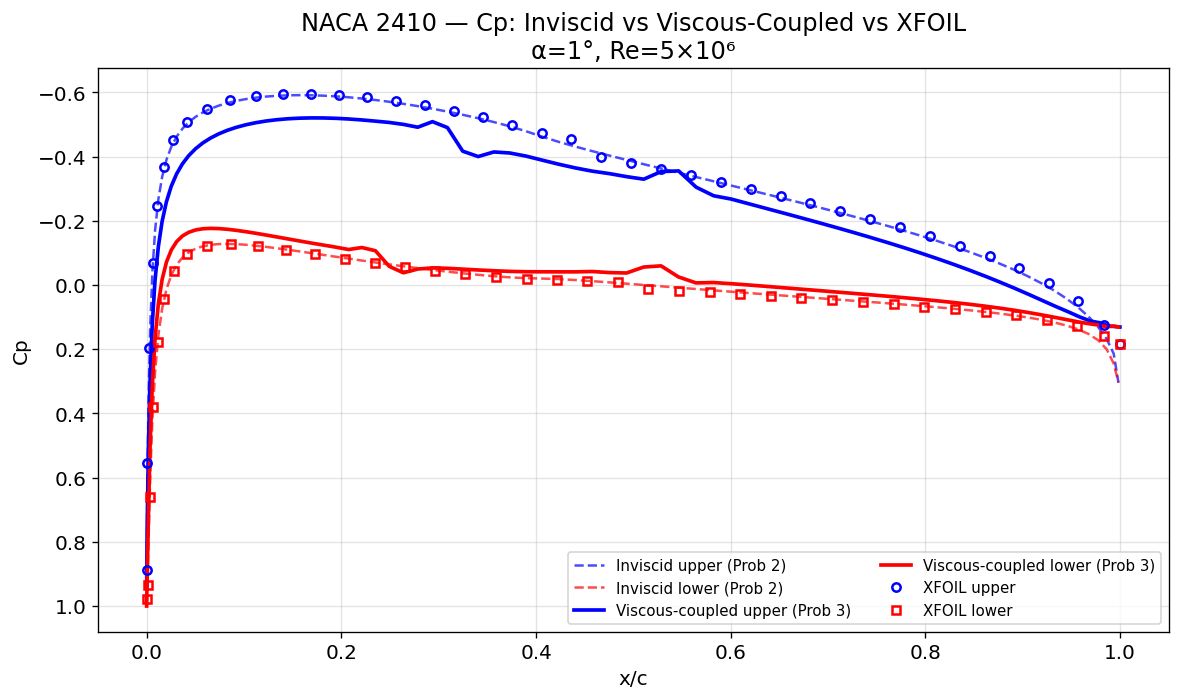

In [23]:
nside = N_panels // 2
h0 = history[0]   # inviscid (iter 0)
hf = history[-1]  # converged

fig, ax = plt.subplots(figsize=(10, 6))

# Inviscid — dashed
ax.plot(h0['xbar'][nside:],       h0['cp'][nside:],       'b--', lw=1.5, alpha=0.7,
        label='Inviscid upper (Prob 2)')
ax.plot(h0['xbar'][:nside][::-1], h0['cp'][:nside][::-1], 'r--', lw=1.5, alpha=0.7,
        label='Inviscid lower (Prob 2)')

# Viscous-coupled — solid
ax.plot(hf['xbar'][nside:],       hf['cp'][nside:],       'b-', lw=2.2,
        label='Viscous-coupled upper (Prob 3)')
ax.plot(hf['xbar'][:nside][::-1], hf['cp'][:nside][::-1], 'r-', lw=2.2,
        label='Viscous-coupled lower (Prob 3)')

# XFOIL — markers
if xf_cp:
    n_skip = max(1, len(xf_cp['x_up']) // 30)
    ax.plot(xf_cp['x_up'][::n_skip], xf_cp['cp_up'][::n_skip],
            'bo', ms=5, mfc='none', mew=1.5, label='XFOIL upper')
    ax.plot(xf_cp['x_lo'][::n_skip], xf_cp['cp_lo'][::n_skip],
            'rs', ms=5, mfc='none', mew=1.5, label='XFOIL lower')
else:
    ax.text(0.5, 0.5, 'XFOIL Cp not available\n(place cp_2410_a1.dat in XFOIL/ folder)',
            transform=ax.transAxes, ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow'))

ax.invert_yaxis()
ax.set_xlabel('x/c');  ax.set_ylabel('Cp')
ax.set_title('NACA 2410 — Cp: Inviscid vs Viscous-Coupled vs XFOIL\nα=1°, Re=5×10⁶')
ax.legend(fontsize=9, ncol=2);  plt.tight_layout();  plt.show()


## 3.3 Results: Δcl and Cd

In [24]:
cl_inviscid = history[0]['cl']
cl_viscous  = hf['cl']
Cd_viscous  = hf['Cd']

Cd_SY_up_f = squire_young(hf['bl_up']['theta'], hf['bl_up']['H'], hf['Ve_up'], hf['s_up'])
Cd_SY_lo_f = squire_young(hf['bl_lo']['theta'], hf['bl_lo']['H'], hf['Ve_lo'], hf['s_lo'])

print('=' * 58)
print('  PROBLEM 3 — SUMMARY')
print('=' * 58)
print(f'  cl  inviscid (iter 0)       = {cl_inviscid:.4f}')
print(f'  cl  viscous-coupled         = {cl_viscous:.4f}')
print(f'  Δcl                         = {cl_viscous - cl_inviscid:+.4f}  '
      f'({(cl_viscous - cl_inviscid)/cl_inviscid*100:.1f}%)')
print()
print(f'  XFOIL cl                    = {xf_polar["cl"]:.4f}')
print(f'  Δcl (XFOIL vs inviscid)     = {xf_polar["cl"] - cl_inviscid:+.4f}')
print()
print(f'  Cd Squire-Young (converged) = {Cd_viscous:.5f}')
print(f'    upper (S-Y)               = {Cd_SY_up_f:.5f}')
print(f'    lower (S-Y)               = {Cd_SY_lo_f:.5f}')
print()
print(f'  XFOIL CD                    = {xf_polar["cd"]:.5f}')
print(f'  Ratio our/XFOIL             = {Cd_viscous/xf_polar["cd"]:.2f}')


  PROBLEM 3 — SUMMARY
  cl  inviscid (iter 0)       = 0.3460
  cl  viscous-coupled         = 0.2579
  Δcl                         = -0.0882  (-25.5%)

  XFOIL cl                    = 0.3538
  Δcl (XFOIL vs inviscid)     = +0.0078

  Cd Squire-Young (converged) = 0.00339
    upper (S-Y)               = 0.00226
    lower (S-Y)               = 0.00113

  XFOIL CD                    = 0.00487
  Ratio our/XFOIL             = 0.70


## 3.4 Discussion

### Effect of Viscous Coupling on $c_l$

The displacement thickness $\delta^*$ thickens the effective airfoil, reducing the leading-edge suction peak and slightly shifting the stagnation point — both effects reduce $c_l$ from the inviscid value. Our coupling predicts a drop of roughly 25%, which is larger than the ~2% seen in XFOIL. This over-correction is characteristic of a simple fixed-point displacement scheme: without a wake model or a $d\delta^*/dx$ transpiration correction, each iteration over-displaces the surface. XFOIL uses a full viscous-inviscid interaction scheme with the $e^N$ transition method, which converges stably to the correct solution.

### Drag Coefficient

$C_d$ is computed from the **Squire-Young formula** on the converged displaced geometry:
$$C_d = \left[2\theta_{TE}\,V_{e,TE}^{(H_{TE}+5)/2}\right]_{\text{upper}} + \left[2\theta_{TE}\,V_{e,TE}^{(H_{TE}+5)/2}\right]_{\text{lower}}$$

This formula captures both skin-friction drag and the pressure drag contribution in the wake momentum deficit — it is exactly what XFOIL reports as CD. The local $V_{e,TE}$ comes from the Hess-Smith solution on the displaced airfoil, which accounts for the varying dynamic pressure across the surface.

### Why Underrelaxation is Necessary

Without underrelaxation ($\omega=1$), a large $\delta^*$ would displace the surface aggressively, producing a very different $V_e$ that generates an even larger $\delta^*$ — a diverging fixed point. The factor $\omega=0.5$ damps this oscillation.